# Prediction of PD - Level 2

In [1]:
!pip install -U pip
!pip install autogluon.tabular[all]

In [2]:
from autogluon.tabular import TabularPredictor, TabularDataset

print("AutoGluon Tabular import ok")

AutoGluon Tabular import ok


In [3]:
!pip install shap lime -q

In [4]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
import numpy as np
import os
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import shutil

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.calibration import calibration_curve


# 0) USER CONFIG

In [5]:
TRAIN_PATH = "/content/train_raw.csv"
VAL_PATH   = "/content/val_raw.csv"
TEST_PATH  = "/content/test_raw.csv"

OUT_DIR = "/content/autogluon_level2_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

PLOT_DIR = "/content/thesis_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "Default"

SEED = 42

CONSERVATISM_UPLIFT = 0.30

APPLY_PD_FLOOR = True
PD_FLOOR = 0.0005

MOC_A_UPLIFT = 0.05

N_BOOT_TEST = 5
N_BOOT_TRAIN = 3
BOOTSTRAP_TIME_LIMIT = 60


# 1) Load fixed splits

In [6]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (153207, 17)
Val shape: (51070, 17)
Test shape: (51070, 17)


In [7]:
train = train.dropna(subset=[TARGET]).copy()
val = val.dropna(subset=[TARGET]).copy()
test = test.dropna(subset=[TARGET]).copy()

train[TARGET] = train[TARGET].astype(int)
val[TARGET] = val[TARGET].astype(int)
test[TARGET] = test[TARGET].astype(int)

# 2) Helper functions

In [8]:
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


def inv_logit(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))


def get_positive_class_proba(predictor, data, positive_class=1, model=None):
    proba = predictor.predict_proba(data, model=model)

    if isinstance(proba, pd.DataFrame):
        if positive_class in proba.columns:
            return proba[positive_class].values
        if str(positive_class) in proba.columns:
            return proba[str(positive_class)].values
        return proba.iloc[:, -1].values

    return np.asarray(proba)[:, -1]


def calibrate_to_target_lradr(pd_values, target_mean, tol=1e-12):
    base_logit = logit(pd_values)

    lower = -20.0
    upper = 20.0

    for _ in range(250):
        alpha = (lower + upper) / 2
        calibrated_pd = inv_logit(base_logit + alpha)

        if abs(calibrated_pd.mean() - target_mean) < tol:
            break

        if calibrated_pd.mean() < target_mean:
            lower = alpha
        else:
            upper = alpha

    return inv_logit(base_logit + alpha), float(alpha)


def apply_final_pd_adjustments(pd_be, moc_a=None, moc_c=None, pd_floor=PD_FLOOR):
    pd_final = np.asarray(pd_be, dtype=float)

    if moc_a is not None:
        pd_final = pd_final + np.asarray(moc_a, dtype=float)

    if moc_c is not None:
        pd_final = pd_final + np.asarray(moc_c, dtype=float)

    if APPLY_PD_FLOOR:
        pd_final = np.maximum(pd_final, pd_floor)

    return np.clip(pd_final, 0, 1)

In [9]:
def bootstrap_moc_c_autogluon(
    train_data,
    eval_data,
    calibration_alpha,
    n_boot=5,
    alpha_q=0.95,
    random_state=42,
):
    rng = np.random.RandomState(random_state)
    all_pd_predictions = []

    train_data = train_data.reset_index(drop=True)
    eval_data = eval_data.reset_index(drop=True)

    for b in range(n_boot):
        sample_idx = rng.randint(0, len(train_data), len(train_data))
        train_boot = train_data.iloc[sample_idx].reset_index(drop=True)

        boot_model_path = os.path.join(OUT_DIR, f"ag_level2_bootstrap_model_{b}")

        predictor_boot = TabularPredictor(
            label=TARGET,
            problem_type="binary",
            eval_metric="average_precision",
            sample_weight='balance_weight',
            path=boot_model_path,
        )

        predictor_boot.fit(
            train_data=train_boot,
            presets="medium_quality",
            time_limit=BOOTSTRAP_TIME_LIMIT,
            verbosity=0,
        )

        pd_raw = get_positive_class_proba(predictor_boot, eval_data)
        pd_calibrated = inv_logit(logit(pd_raw) + calibration_alpha)

        all_pd_predictions.append(pd_calibrated)

        if os.path.exists(boot_model_path):
            shutil.rmtree(boot_model_path, ignore_errors=True)

    pred_matrix = np.vstack(all_pd_predictions)

    pd_mean = pred_matrix.mean(axis=0)
    pd_quantile = np.quantile(pred_matrix, alpha_q, axis=0)

    moc_c = np.maximum(pd_quantile - pd_mean, 0.0)

    return pd_mean, moc_c, pred_matrix

# 3) AutoGluon initial training + hyperparameter tuning

In [10]:
predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
     eval_metric="average_precision",
    sample_weight='balance_weight',
    path=f"{OUT_DIR}/ag_model_initial"
)

predictor.fit(
    train_data=train,
    tuning_data=val,
    presets="best_quality",
    use_bag_holdout=True,
    time_limit=600
)


best_model = predictor.model_best

print("Best initial model:", best_model)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       8.79 GB / 12.67 GB (69.4%)
Disk Space Avail:   75.11 GB / 107.72 GB (69.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Using predefined sample weighting strategy: balance_weight. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save

Best initial model: WeightedEnsemble_L3


## 3.1) AutoGluon final refit on train & validation

In [11]:
# refit_full() --> The selected models are retrained on the complete development dataset, consisting of both the training and validation partitions

predictor.refit_full()

best_model_final = predictor.model_best

print("Best final model:", best_model_final)

Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more, refer to the `.refit_full` method docstring which explains how "_FULL" models differ from normal models.
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.1/7.1 GB
	13.72s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBM_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.1/7.0 GB
	11.53s	 = Training   runtime
Fitting model: WeightedEnsemble_L2_FULL | Skipping fit via cloning parent ...
	Ensemble Weights: {'LightGBMXT_BAG_L1': 0.955, 'LightGBM_BAG_L1': 0.045}
	0.84s	 = Training   runtime
Fitting

Best final model: WeightedEnsemble_L3_FULL


# 4) Evaluation on unseen test set

In [12]:
test_results = predictor.evaluate(
    test,
    model=best_model_final
)

print(test_results)

{'average_precision': np.float64(0.33260582664067884), 'accuracy': 0.6989622087331114, 'balanced_accuracy': np.float64(0.6907210078295071), 'mcc': np.float64(0.2574662690712434), 'roc_auc': np.float64(0.7583296846438204), 'f1': 0.3441126279863481, 'precision': 0.23033868296304758, 'recall': 0.6799865115494858}


# 5) Leaderboard

In [13]:
leaderboard = predictor.leaderboard(
    test,
    extra_metrics=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "log_loss"
    ],
    silent=True
)

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_test.csv"),
    index=False
)

                      model  score_test  accuracy  balanced_accuracy  \
0         LightGBMXT_BAG_L1    0.334039  0.694341           0.690450   
1       WeightedEnsemble_L2    0.333977  0.694478           0.690381   
2       WeightedEnsemble_L3    0.333275  0.697709           0.689719   
3         LightGBMXT_BAG_L2    0.332625  0.699295           0.690104   
4  WeightedEnsemble_L3_FULL    0.332606  0.698962           0.690721   
5  WeightedEnsemble_L2_FULL    0.332082  0.691952           0.690417   
6    LightGBMXT_BAG_L2_FULL    0.331972  0.700137           0.689994   
7    LightGBMXT_BAG_L1_FULL    0.331904  0.692031           0.690900   
8      LightGBM_BAG_L1_FULL    0.330250  0.691600           0.688680   
9           LightGBM_BAG_L1    0.329165  0.694733           0.688035   

         f1  log_loss  score_val        eval_metric  pred_time_test  \
0  0.342460 -0.576515   0.321021  average_precision       11.504630   
1  0.342450 -0.576492   0.321024  average_precision       17.4720

# 6) Calibration

In [14]:
train_final = pd.concat([train, val], axis=0).reset_index(drop=True)
test_final = test.copy().reset_index(drop=True)

y_train_final = train_final[TARGET].astype(int).values
y_test_final = test_final[TARGET].astype(int).values

# Raw AutoGluon PDs
pd_train_raw = get_positive_class_proba(
    predictor,
    train_final,
    model=best_model_final
)

pd_test_raw = get_positive_class_proba(
    predictor,
    test_final,
    model=best_model_final
)

# Best-estimate calibration to proxy LRADR
observed_train_dr = float(np.mean(y_train_final))

proxy_lradr = observed_train_dr * (1 + CONSERVATISM_UPLIFT)
proxy_lradr = min(max(proxy_lradr, 1e-6), 1 - 1e-6)

pd_train_be, alpha_shift = calibrate_to_target_lradr(
    pd_train_raw,
    proxy_lradr
)

pd_test_be = inv_logit(logit(pd_test_raw) + alpha_shift)

# MoC_C via bootstrap
pd_train_boot_mean, moc_c_train, pred_matrix_train = bootstrap_moc_c_autogluon(
    train_data=train_final,
    eval_data=train_final,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TRAIN,
    alpha_q=0.95,
    random_state=SEED,
)

pd_test_boot_mean, moc_c_test, pred_matrix_test = bootstrap_moc_c_autogluon(
    train_data=train_final,
    eval_data=test_final,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TEST,
    alpha_q=0.95,
    random_state=SEED + 1,
)

# MoC_A
moc_a_train = pd_train_be * MOC_A_UPLIFT
moc_a_test = pd_test_be * MOC_A_UPLIFT

# Final PDs
pd_train_final = apply_final_pd_adjustments(
    pd_be=pd_train_be,
    moc_a=moc_a_train,
    moc_c=moc_c_train,
    pd_floor=PD_FLOOR,
)

pd_test_final = apply_final_pd_adjustments(
    pd_be=pd_test_be,
    moc_a=moc_a_test,
    moc_c=moc_c_test,
    pd_floor=PD_FLOOR
)

print("Observed train DR:", observed_train_dr)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print("Mean MoC_A test:", np.mean(moc_a_test))
print("Mean MoC_C test:", np.mean(moc_c_test))
print("Mean final PD test:", np.mean(pd_test_final))

Observed train DR: 0.11612663197521013
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.6826599081468885
Mean MoC_A test: 0.0076007027853828716
Mean MoC_C test: 0.02973439263023033
Mean final PD test: 0.18934915112327064


# 7) AutoGluon explainability

In [15]:
EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
os.makedirs(EXPLAIN_DIR, exist_ok=True)

best_test_model = leaderboard.iloc[0]["model"]

print(
    "Best model on test leaderboard (reported only):",
    best_test_model
)


Best model on test leaderboard (reported only): LightGBMXT_BAG_L1


# 8) Prepare data

In [16]:
X_train = train_final.drop(columns=[TARGET]).copy()
y_train = train_final[TARGET].astype(int)

X_test = test_final.drop(columns=[TARGET]).copy()
y_test = test_final[TARGET].astype(int)

# 9) SHAP KernelExplainer

In [17]:
# explain final calibrated PD-Pipeline

X_background = X_train.sample(
    n=min(20, len(X_train)),
    random_state=42
)

X_shap = X_test.sample(
    n=min(30, len(X_test)),
    random_state=42
)


def predict_proba_fn(data):

    df = pd.DataFrame(
        data,
        columns=X_train.columns
    )

    pd_raw = get_positive_class_proba(
        predictor,
        df,
        model=best_model_final
    )

    pd_be = inv_logit(
        logit(pd_raw) + alpha_shift
    )

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    pd_final = apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
        pd_floor=PD_FLOOR
    )

    return pd_final


explainer = shap.KernelExplainer(
    predict_proba_fn,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=3.129e-03, with an active set of 1 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.797e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.980e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=1.791e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 2

## 9.1)  SHAP Summary Plot

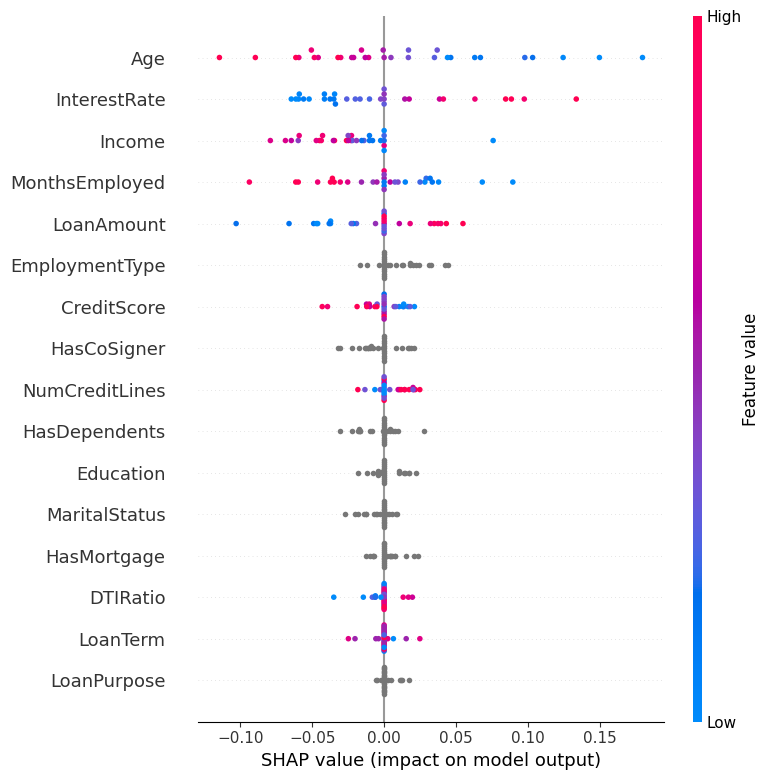

In [18]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## 9.2) SHAP Bar Plot

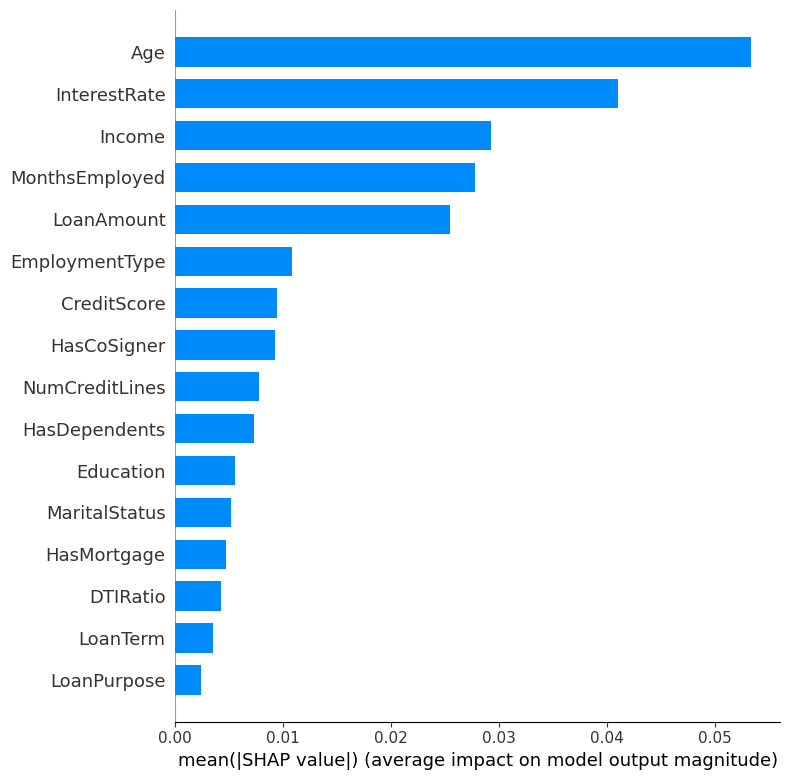

In [19]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_bar_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# 10) LIME

In [20]:
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["Non-Default", "Default"],
    mode="classification"
)

def predict_final_pd_from_encoded(data):

    df_encoded = pd.DataFrame(
        data,
        columns=X_train_lime.columns
    )

    df_original = pd.DataFrame(index=df_encoded.index)

    for col in X_train.columns:

        dummy_cols = [
            c for c in df_encoded.columns
            if c.startswith(f"{col}_")
        ]

        if dummy_cols:

            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )

        else:
            df_original[col] = df_encoded[col]

    pd_raw = get_positive_class_proba(
        predictor,
        df_original,
        model=best_model_final
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test)
    )

    return apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

def predict_proba_fn_lime(data):
    pd_final =  predict_final_pd_from_encoded(data)

    return np.column_stack([
        1 - pd_final,
        pd_final
    ])

instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## 10.1) Save LIME explanation

In [21]:
lime_exp.save_to_file(
    os.path.join(OUT_DIR, "lime_explanation.html")
)

print("Level 2 explainability outputs saved.")

Level 2 explainability outputs saved.


# 11) Global permutation feature importance

In [22]:
# Feature importance computed by shuffling one feature at a time and measuring the resulting performance drop
# Higher values indicate stronger contribution to predictive performance.
# Negative values can indicate that a feature is harmful or unstable.

feature_importance = predictor.feature_importance(
    data=test,
    model=best_model_final,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance)

feature_importance.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_best_model.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
Age               0.096549  0.014728  3.307261e-09  10  0.111684  0.081413
Income            0.088474  0.009660  1.699272e-10  10  0.098401  0.078547
InterestRate      0.058355  0.009182  4.348402e-09  10  0.067791  0.048919
LoanAmount        0.056657  0.010672  2.112839e-08  10  0.067624  0.045690
MonthsEmployed    0.031181  0.005114  6.264337e-09  10  0.036437  0.025926
EmploymentType    0.009269  0.004302  3.890611e-05  10  0.013690  0.004848
HasCoSigner       0.006632  0.002984  3.068814e-05  10  0.009698  0.003565
CreditScore       0.003391  0.003670  8.488762e-03  10  0.007162 -0.000380
HasDependents     0.003282  0.002737  2.134860e-03  10  0.006096  0.000469
LoanPurpose       0.003054  0.002359  1.351619e-03  10  0.005479  0.000629
Education         0.002977  0.002948  5.474900e-03  10  0.006006 -0.000053
MaritalStatus     0.002726  0.002080  1.252667e-03  10  0.004863  0.000588
HasMortgage       0.00196

# 12) Feature importance for the full AutoGluon predictor

In [23]:
# If the best model is an ensemble --> can be interpreted as the importance of the final "prediction system" rathen than only one base model

feature_importance_final = predictor.feature_importance(
    data=test,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance_final)

feature_importance_final.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_final_predictor.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
Age               0.096549  0.014728  3.307261e-09  10  0.111684  0.081413
Income            0.088474  0.009660  1.699272e-10  10  0.098401  0.078547
InterestRate      0.058355  0.009182  4.348402e-09  10  0.067791  0.048919
LoanAmount        0.056657  0.010672  2.112839e-08  10  0.067624  0.045690
MonthsEmployed    0.031181  0.005114  6.264337e-09  10  0.036437  0.025926
EmploymentType    0.009269  0.004302  3.890611e-05  10  0.013690  0.004848
HasCoSigner       0.006632  0.002984  3.068814e-05  10  0.009698  0.003565
CreditScore       0.003391  0.003670  8.488762e-03  10  0.007162 -0.000380
HasDependents     0.003282  0.002737  2.134860e-03  10  0.006096  0.000469
LoanPurpose       0.003054  0.002359  1.351619e-03  10  0.005479  0.000629
Education         0.002977  0.002948  5.474900e-03  10  0.006006 -0.000053
MaritalStatus     0.002726  0.002080  1.252667e-03  10  0.004863  0.000588
HasMortgage       0.00196

# 13) Predictions

In [24]:
pd_val_raw = get_positive_class_proba(predictor, val, model=best_model_final)
pd_val_be = inv_logit(logit(pd_val_raw) + alpha_shift)
moc_a_val = pd_val_be * MOC_A_UPLIFT
moc_c_val = np.full_like(pd_val_be, np.mean(moc_c_train), dtype=float)

pd_val_final = apply_final_pd_adjustments(
    pd_be=pd_val_be,
    moc_a=moc_a_val,
    moc_c=moc_c_val,
    pd_floor=PD_FLOOR,
)

y_test_true = y_test_final
y_test_proba = pd_test_be


# 14) Lorenz Curve & Calibration Curve

Discrimination and calibration evaluate different properties:

*   Discrimination: Can the model rank risky and safe borrowers correctly?
*   Calibration: Do predicted PD values match observed default rates?

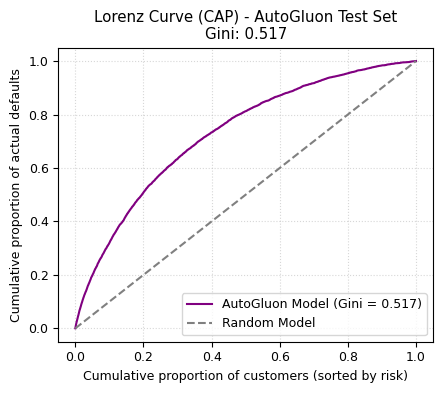

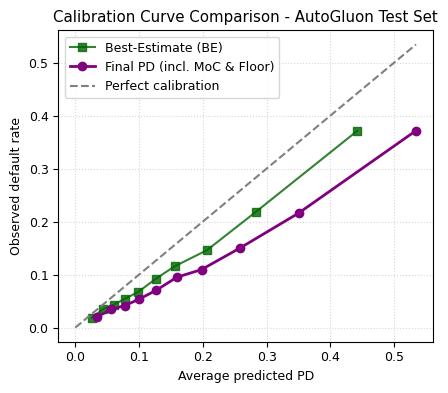

Saved AutoGluon IRBA-compliant plots to: /content/thesis_plots


In [25]:
plt.rcParams.update({
    "font.size": 9
})

# ============================================================
# 1. Lorenz curve (CAP / Cumulative Gains) - AutoGluon
# ============================================================

# Evaluate the discriminatory power of the PD model.
# Customers are sorted from highest predicted risk to lowest.
#
# Interpretation:
# - A curve far above the diagonal indicates strong risk separation.
# - The diagonal represents a random model.
# - The Gini coefficient summarizes discrimination:
#
#   Gini < 0.20  -> weak
#   0.20 - 0.40  -> acceptable
#   0.40 - 0.50  -> good
#   > 0.50       -> strong
#
# In banking practice, Gini is one of the standard measures
# for validating rating systems and PD models.

# Create DataFrame and sort observations by predicted PD
df_lorenz = pd.DataFrame({"y_true": y_test_true, "y_proba": y_test_proba})
df_lorenz = df_lorenz.sort_values(by="y_proba", ascending=False).reset_index(drop=True)

# Cumulative percentage of customers
cum_population = np.arange(1, len(df_lorenz) + 1) / len(df_lorenz)
# Cumulative percentage of observed defaults
cum_defaults = df_lorenz["y_true"].cumsum() / df_lorenz["y_true"].sum()

# Convert ROC-AUC into Gini coefficient
roc_auc = roc_auc_score(y_test_true, y_test_proba)
gini_score = 2 * roc_auc - 1

plt.figure(figsize=(4.5, 4))
plt.plot(cum_population, cum_defaults, color="purple", label=f"AutoGluon Model (Gini = {gini_score:.3f})")
# Random model benchmark
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("Cumulative proportion of customers (sorted by risk)")
plt.ylabel("Cumulative proportion of actual defaults")
plt.title(f"Lorenz Curve (CAP) - AutoGluon Test Set\nGini: {gini_score:.3f}")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
lorenz_path = os.path.join(PLOT_DIR, "lorenz_curve_ag_test.png")
plt.savefig(lorenz_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# 2. Combined Calibration Curve (Reliability Diagram) - AutoGluon
# ============================================================
# Purpose:
# Evaluate whether predicted PD values correspond to observed default frequencies.
#
# This plot compares two distinct stages of the IRBA model pipeline:
#
# 1) Best-Estimate (BE) PD:
#    Represents the unbiased estimate of the expected default probability after the
#    alpha-shift calibration step. It is evaluated before applying conservatism adjustments
#    such as MoC_A, MoC_C, or the regulatory PD floor. A well-calibrated BE model should
#    closely follow the diagonal reference line across all risk segments.
#
# 2) Final PD:
#    Evaluated after conservatism adjustments (MoC and the PD floor). Therefore, the final
#    PD is expected to be conservative. For final PDs, points slightly below the diagonal
#    are not necessarily problematic, because MoC intentionally increases the PD estimate.
#    This line indicates the built-in level of regulatory conservatism.
#
# Interpretation:
# - Points on the diagonal indicate perfect calibration.
#
# - Points above the diagonal:
#     Observed default rate > predicted PD -> the model underestimates risk.
#
# - Points below the diagonal:
#     Observed default rate < predicted PD -> the model overestimates risk / applies conservatism.

# 1. Split observations into 10 equally populated risk buckets for Best-Estimate
prob_true_be, prob_pred_be = calibration_curve(
    y_test_final,
    pd_test_be,       # BE-probability after Alpha-shift
    n_bins=10,
    strategy="quantile"
)

# 2. Split observations into 10 equally populated risk buckets for Final PD
prob_true_final, prob_pred_final = calibration_curve(
    y_test_true,
    pd_test_final,     # Final AutoGluon PD (incl. MoC & Floor)
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(4.5, 4))

# Plot Best-Estimate Line (Green)
plt.plot(prob_pred_be, prob_true_be, "s-", color="darkgreen", alpha=0.8, label="Best-Estimate (BE)")

# Plot Final PD Line (Purple für AutoGluon)
plt.plot(prob_pred_final, prob_true_final, "o-", color="purple", lw=2, label="Final PD (incl. MoC & Floor)")

# Perfect calibration benchmark reference line (up to the maximum predicted value)
max_val = max(max(prob_pred_be), max(prob_pred_final)) if len(prob_pred_final) > 0 else 1.0
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve Comparison - AutoGluon Test Set")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
calib_path = os.path.join(PLOT_DIR, "calibration_curve_comparison_ag_test.png")
plt.savefig(calib_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved AutoGluon IRBA-compliant plots to:", PLOT_DIR)


## 14.1) Save output

In [26]:
# calculate Gini-coefficient
auc_be = roc_auc_score(y_test_final, pd_test_be)
gini_be = 2 * auc_be - 1

auc_final = roc_auc_score(y_test_final, pd_test_final)
gini_final = 2 * auc_final - 1

# Calculate calibration quality using the Brier Score
# Lower values indicate better calibration and probability accuracy.
brier_be = brier_score_loss(y_test_final, pd_test_be)
brier_final = brier_score_loss(y_test_final, pd_test_final)

# Store all evaluation metrics in a DataFrame
irba_metrics_summary = pd.DataFrame({
    "Model_Stage": ["Best-Estimate (BE)", "Final (incl. MoC & Floor)"],
    "Gini_Coefficient": [gini_be, gini_final],
    "Brier_Score_Calibration": [brier_be, brier_final]
})

# save as csv
irba_metrics_summary.to_csv(os.path.join(OUT_DIR, "irba_performance_metrics.csv"), index=False)


print("H2O CORE IRBA PERFORMANCE METRICS (TEST SET)")
print(irba_metrics_summary.to_string(index=False))


H2O CORE IRBA PERFORMANCE METRICS (TEST SET)
              Model_Stage  Gini_Coefficient  Brier_Score_Calibration
       Best-Estimate (BE)          0.516659                 0.092469
Final (incl. MoC & Floor)          0.514009                 0.098412
